In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from rich.console import Console
from rich.table import Table
from rich.progress import track
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


Importiamo i dati e facciamo padding

In [2]:
data_dir = r'C:\Users\albic\OneDrive\Documenti\Immagini\Desktop\Machine learning\ECG_recording_local\training2017'  
target_len = 9000

ref = pd.read_csv(
    os.path.join(data_dir, r'C:\Users\albic\OneDrive\Documenti\Immagini\Desktop\Machine learning\ECG_recording_local\training2017\REFERENCE-original.csv'),
    header=None,
    names=['record', 'label']
)

def fix_length(v, target_len):
    v = np.squeeze(v)
    n = v.size

    if n == target_len:
        return v

    if n > target_len:
        # crop centrale (puoi scegliere anche dall'inizio: v[:target_len])
        start = (n - target_len) // 2
        return v[start:start + target_len]

    # n < target_len: padding con zeri in coda
    pad_width = target_len - n
    return np.pad(v, (0, pad_width))

signals = []
labels = []

for rec, lab in zip(ref['record'], ref['label']):
    mat_path = os.path.join(data_dir, rec + '.mat')
    if lab != '~':
        if not os.path.exists(mat_path):
            continue

        d = sio.loadmat(mat_path)
        v = d['val']   # (1, n) in generale

        v_fixed = fix_length(v, target_len)
        signals.append(v_fixed)
        labels.append(lab)
    

X = np.stack(signals, axis=0)   # (N_record, 9000)
y = np.array(labels)

mapping = {'N': 0, 'A': 1, 'O': 1}
y = np.array([mapping[lab] for lab in labels])


print(f"Dimensioni finali: X={X.shape}, y={y.shape}")

Dimensioni finali: X=(8482, 9000), y=(8482,)


Facciamo normalizzazione

In [3]:
def normalize_ecg(matrix):
    means = np.mean(matrix, axis=1, keepdims=True)
    stds = np.std(matrix, axis=1, keepdims=True)
    stds[stds == 0] = 1e-8 
    return (matrix - means) / stds

X_norm = normalize_ecg(X)

# 3. AGGIUNTA DIMENSIONE (Per Keras)
# X_ready = np.expand_dims(X_norm, axis=-1)

# 4. DIVISIONE 80/20 (Train e Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Mantiene le proporzioni delle classi AFib e Normal!
)

print(f"Dataset pronto! Dimensioni:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Dataset pronto! Dimensioni:
X_train: (6785, 9000)
X_test: (1697, 9000)


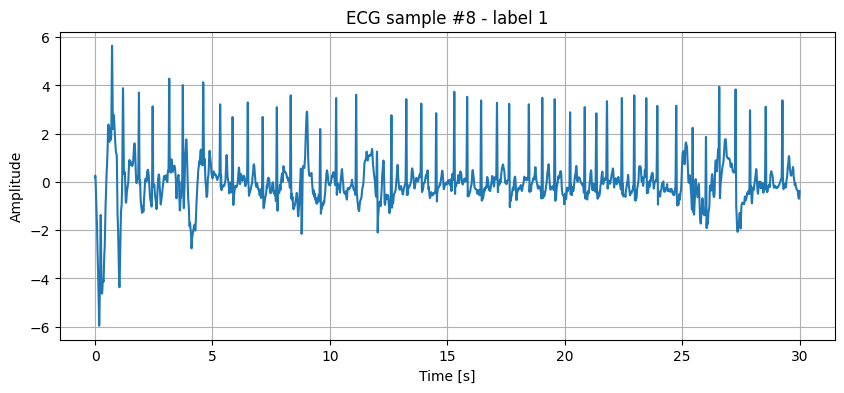

In [4]:
i = 8  # indice del record che si  vede
v = X_norm[i]
fs = 300
t = np.arange(v.size) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, v)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'ECG sample #{i} - label {y[i]}')
plt.grid(True)
plt.show()

Addestriamo un modello RandomForest che classifica Normal Vs Non-Normal 

In [7]:
g0 = X_train[y_train == 0]  # Tutte le righe dove y è 0 (Rumore/Background)
g1 = X_train[y_train == 1]  # Tutte le righe dove y è 1 (Bosone/Signal)

data0 = g0.astype(np.float64)
data1 = g1.astype(np.float64)

# --- Calcolo delle dimensioni (quante righe/campioni ci sono) ---

N0 = data0.shape[0]
N1 = data1.shape[0]

data = np.vstack([data0, data1])                # (N0+N1, 32*509)
labels = np.hstack((np.zeros(N0), np.ones(N1))) # np.hstack affianca un array di 0 e un array di 1

# --- Creiamo un array che va da 0 fino a (N0+N1 - 1) ---

original_indices = np.arange(N0 + N1)
NNeg = N0
NPos = N1

# --- Parametri di training ---

K = 5

rf_model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 5}, n_jobs=-1)

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

# Inizializziamo la console di Rich
console = Console()

# Prepariamo la tabella stilizzata
table = Table(title="🔬 Risultati Normal vs Non-Normal - K-Fold Cross Validation", header_style="bold magenta", border_style="cyan")
table.add_column("Fold", justify="center", style="dim")
table.add_column("Accuracy", justify="right")
table.add_column("Sensitivity", justify="right")
table.add_column("Specificity", justify="right")

acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    print(f"Fold {fold_number}")
    # fase di training
    rf_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = rf_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    # Aggiungiamo la riga del fold alla tabella
    table.add_row(
        f"#{fold_number}", 
        f"{accuracy*100:.2f}%", 
        f"{sensitivity*100:.2f}%", 
        f"{specificity*100:.2f}%"
    )
    fold_number +=1

# --- Calcolo Medie e Deviazioni Standard ---
acc_mean, acc_std = np.mean(acc_results)*100, np.std(acc_results)*100
sens_mean, sens_std = np.mean(sens_results)*100, np.std(sens_results)*100
spec_mean, spec_std = np.mean(spec_results)*100, np.std(spec_results)*100

'''print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}% ± {acc_std:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}% ± {sens_std:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}% ± {spec_std:.2f}%")
print('--------------------')'''

# Aggiungiamo una riga di separazione e la riga finale della MEDIA
table.add_section()
table.add_row(
    "[bold yellow]MEDIA[/]", 
    f"[bold yellow]{acc_mean:.2f}% ± {acc_std:.2f}%[/]", 
    f"[bold yellow]{sens_mean:.2f}% ± {sens_std:.2f}%[/]", 
    f"[bold yellow]{spec_mean:.2f}% ± {spec_std:.2f}%[/]"
)

# Stampiamo tutto!
console.print("\n")
console.print(table)
console.print(f"[dim]Modello utilizzato: {rf_model.__class__.__name__}\n")
acc_results_all_channels = np.mean(acc_results)

--------------------
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


🔬 Risultati Normal vs Non-Normal - K-Fold Cross Validation
┏━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Fold  ┃       Accuracy ┃   Sensitivity ┃    Specificity ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│  #1   │         60.57% │         5.45% │         96.12% │
│  #2   │         60.87% │         5.08% │         96.85% │
│  #3   │         61.31% │         4.70% │         97.82% │
│  #4   │         60.50% │         6.38% │         95.51% │
│  #5   │         60.35% │         6.00% │         95.51% │
├───────┼────────────────┼───────────────┼────────────────┤
│ MEDIA │ 60.72% ± 0.34% │ 5.52% ± 0.61% │ 96.36% ± 0.88% │
└───────┴────────────────┴───────────────┴────────────────┘

Modello utilizzato: RandomForestClassifier

Ciclo per il miglior K

In [9]:
NUMK = 11

acc_numk = [] # array di accuracy in funzione di numk

for numk in range(2, NUMK +1):
    
    skf = StratifiedKFold(n_splits=numk, shuffle=True, random_state=1)
    rf_model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 5}, n_jobs=-1)
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numk.append(np.mean(acc_folds))

# --- Plot accuracy vs K numero di fold ---

plt.figure()
plt.plot(np.arange(2, NUMK+1), acc_numk, marker='o', color='b', linewidth=1, markersize=3)
plt.xlabel('K numero di fold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di fold (Random Forest)')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

KeyboardInterrupt: 

PCA RandomForest

In [ ]:
NUMVAR = 400

acc_numvar = [] # array di accuracy in funzione di numvar

for numvar in range(1, NUMVAR +1):
    
    rf_model = RandomForestClassifier(class_weight={0: 1, 1: 10})

    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index, :numvar], data[test_index, :numvar]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numvar.append(np.mean(acc_folds))

# --- Plot accuracy vs numero di features ---

plt.figure()
plt.plot(np.arange(1, NUMVAR+1), acc_numvar, marker='o', color = 'b', markersize=3, linewidth=0.75)
plt.xlabel('Numero di feature')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di feature (SVM lineare)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

Nuovo modello RandomForest per classificare AF e Other

Fare un grid search per trovare i parametri migliori

In [ ]:

# Supponiamo che 'data' e 'labels' siano già stati creati correttamente dal tuo codice precedente

# 1. Creiamo la Pipeline esplicita
# Diamo un nome ("scaler" e "svm") a ogni passaggio. Questo è FONDAMENTALE
# per dire al Grid Search esattamente a quale step applicare i parametri.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# 2. La Griglia dei Parametri (Il "Menù" delle prove)
# Nota la sintassi: nome_step__nome_parametro (es. svm__C) con DUE underscore!
param_grid = {
    'svm__C': [0.1, 1, 10, 100],                 # Regola la "severità" dei margini (regolarizzazione)
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],    # Tipi di confini di decisione
    'svm__gamma': ['scale', 'auto']              # Importante per i kernel rbf e poly
}

# 3. Impostiamo il K-Fold come avevi fatto tu
# Consiglio: metti random_state=42 al posto di False per rendere i risultati riproducibili!
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Inizializziamo il Grid Search
print("Inizio Grid Search... (Allaccia le cinture, potrebbe volerci un po'!) 🚀")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,               # Gli passiamo il tuo K-Fold a 5 split
    scoring='accuracy',   # Vogliamo trovare i parametri che massimizzano l'Accuracy
    n_jobs=-1,            # MAGIA: usa TUTTI i core del tuo processore per velocizzare
    verbose=2             # Stampa a schermo cosa sta facendo
)

# 5. Facciamo partire l'addestramento intensivo
grid_search.fit(data, labels)

# 6. Risultati Finali
print('\n' + '-'*40)
print("🎯 RICERCA COMPLETATA!")
print('-'*40)
print(f"Migliori Parametri Trovati:\n{grid_search.best_params_}")
print(f"Migliore Accuracy Media: {grid_search.best_score_ * 100:.2f}%")
print('-'*40)

# Il modello con i parametri perfetti è già pronto all'uso qui:
best_model = grid_search.best_estimator_

# Puoi usarlo direttamente per predire nuovi dati:
# predizioni = best_model.predict(nuovi_dati)

Addestriamo un modello SVM che classifica Normal Vs Non-Normal 

In [ ]:
# --- Parametri di training ---

K = 5
#svm_model = SVC(kernel='linear')   # usiamo kernel lineare

svm_model = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', C=1.0)
    )

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=False)

acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    # fase di training
    svm_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = svm_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    # stampiamo i risultati
    print(f"Fold {fold_number}:     "
          f"Accuracy = {accuracy * 100:.2f}%     "
          f"Sensitivity = {sensitivity * 100:.2f}%     "
          f"Specificity = {specificity * 100:.2f}%     ")
    
    fold_number +=1
    
# --- CALCOLO DEVIAZIONE STANDARD ---
acc_std = np.std(acc_results) * 100
sens_std = np.std(sens_results) * 100
spec_std = np.std(spec_results) * 100

print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}% ± {acc_std:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}% ± {sens_std:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}% ± {spec_std:.2f}%")
print('--------------------')
acc_results_all_channels = np.mean(acc_results)

Ciclo per il miglior K

In [ ]:
NUMK = 11

acc_numk = [] # array di accuracy in funzione di numvar

for numk in range(2, NUMK +1):
    
    skf = StratifiedKFold(n_splits=numk, shuffle=True, random_state=1)
    svm_model = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', C=1.0)
    )
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        svm_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = svm_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numk.append(np.mean(acc_folds))

# --- Plot accuracy vs K numero di fold ---

plt.figure()
plt.plot(np.arange(2, NUMK+1), acc_numk, marker='o', color='b', linewidth=1, markersize=3)
plt.xlabel('K numero di fold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di fold (SVM lineare)')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

PCA SVM

Accuracy vs numero di feature

In [ ]:

NUMVAR = 400

acc_numvar = [] # array di accuracy in funzione di numvar

for numvar in range(1, NUMVAR +1):
    
    svm_model = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', C=1.0)
    )
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index, :numvar], data[test_index, :numvar]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        svm_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = svm_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numvar.append(np.mean(acc_folds))

# --- Plot accuracy vs numero di features ---

plt.figure()
plt.plot(np.arange(1, NUMVAR+1), acc_numvar, marker='o', color = 'b', markersize=3, linewidth=0.75)
plt.xlabel('Numero di feature')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di feature (SVM lineare)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

Nuovo modello SVM per classificare AF e Other

Rete neurale